In [15]:
import torch
from components.datasets import load_dataset
from components.models import init_mf_params, create_anfis_model
from components.trainer import train_model
import numpy as np

# Config
config = {
    "dataset": "breast-cancer-wisconsin", # options: mackey-glass, circles, spiral, moons, swiss-roll, iris, digits, cryotherapy, pima, haberman, immunotherapy, thyroid, mnist, breast-cancer-wisconsin, adult-income, bank-marketing, car-evaluation, credit-card
    "mf_type": "advanced", # options: simple, advanced
    "mf_init": "random_uniform", # options: fcm, random_uniform
    "K": 3, # number of rules (MFs per input)
    "s_mode": "alpha_beta",
    "n_epochs": 1000,
    "lr": 0.001,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,
}

# 1) Load dataset
X_train, X_test, y_train, y_test, task_type, n_outputs = load_dataset(config["dataset"])

# 2) Initialize MF
centers_init, spreads_init = init_mf_params(
    X_train, K=config["K"], method=config["mf_init"], scale=1.0, seed=config["seed"]
)

# 3) Create model
model = create_anfis_model(
    config["mf_type"], centers_init, spreads_init, n_outputs=n_outputs, s_mode=config["s_mode"]
).to(config["device"])



task_type: classification
n_outputs: 1
y unique: [0 1]
epoch    1 | train_loss=0.720689 | val_loss=0.689627, acc=0.5526
epoch  100 | train_loss=0.158459 | val_loss=0.186998, acc=0.9649
epoch  200 | train_loss=0.107639 | val_loss=0.135646, acc=0.9737
epoch  300 | train_loss=0.088032 | val_loss=0.115626, acc=0.9825
epoch  400 | train_loss=0.077440 | val_loss=0.104856, acc=0.9825
epoch  500 | train_loss=0.070628 | val_loss=0.098032, acc=0.9737
epoch  600 | train_loss=0.065827 | val_loss=0.093056, acc=0.9737
epoch  700 | train_loss=0.062294 | val_loss=0.089081, acc=0.9737
epoch  800 | train_loss=0.059506 | val_loss=0.085920, acc=0.9737
epoch  900 | train_loss=0.057292 | val_loss=0.083421, acc=0.9649
epoch 1000 | train_loss=0.055445 | val_loss=0.081429, acc=0.9649

Final Results:
Mode: alpha_beta
Train: accuracy rate 0.989 (450/455) | error 0.011 (5)
Test: accuracy rate 0.965 (110/114) | error 0.035 (4)


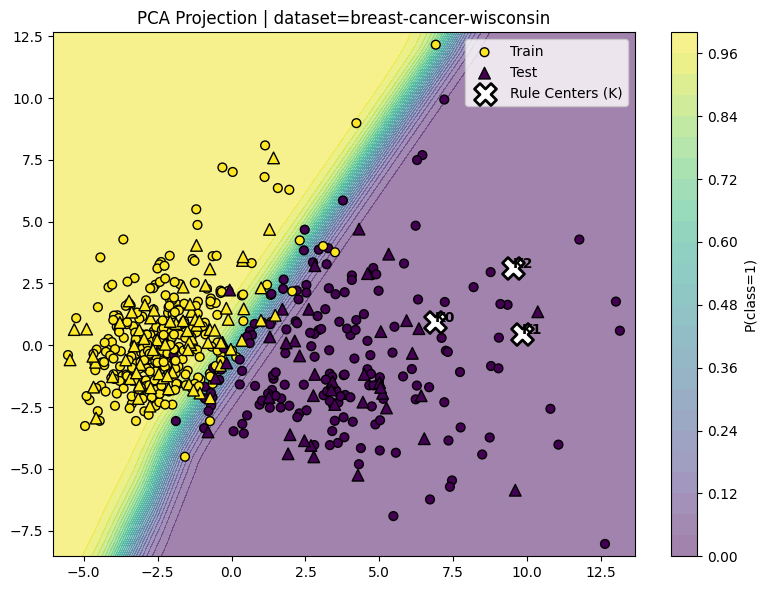







In [16]:
from components.utils import evaluate_anfis_model

print("task_type:", task_type)
print("n_outputs:", n_outputs)
print("y unique:", np.unique(y_train))


# 4) Train
model = train_model(
    model,
    X_train, y_train,
    X_test, y_test,
    task_type=task_type,
    n_outputs=n_outputs,
    n_epochs=config["n_epochs"],
    lr=config["lr"],
    device=config["device"],
)


# 5) Evaluate and plot results
evaluate_anfis_model(
    model, X_train, y_train, X_test, y_test, 
    device=config["device"], 
    s_mode_choice=config["s_mode"], 
    centers_init=centers_init,
    dataset_name=config["dataset"] 
)